In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('swiggy.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19.0,3.0,saturday,1.0,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25.0,3.0,friday,0.0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19.0,3.0,saturday,1.0,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5.0,4.0,tuesday,0.0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26.0,3.0,saturday,1.0,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34202,AURGRES01DEL02,35.0,4.4,19.876219,75.346017,19.896219,75.366017,2022-02-11,windy,low,...,AURG,11.0,2.0,friday,0.0,5.0,8.0,morning,3.052738,short
34203,COIMBRES17DEL03,39.0,4.7,11.026117,76.944652,11.056117,76.974652,2022-03-07,sandstorms,medium,...,COIMB,7.0,3.0,monday,0.0,10.0,17.0,evening,4.674144,short
34204,BANGRES17DEL01,25.0,5.0,12.972532,77.608179,13.082532,77.718179,2022-03-27,sunny,jam,...,BANG,27.0,3.0,sunday,1.0,10.0,21.0,night,17.076713,very_long
34205,INDORES18DEL02,31.0,4.8,22.753839,75.897429,22.773839,75.917429,2022-03-24,sunny,low,...,INDO,24.0,3.0,thursday,0.0,5.0,11.0,morning,3.025060,short


In [ ]:
columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2.0,snack,motorcycle,0.0,no,urban,24.0,1.0,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2.0,snack,scooter,1.0,no,metropolitian,33.0,0.0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0.0,drinks,motorcycle,1.0,no,urban,26.0,1.0,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0.0,buffet,motorcycle,1.0,no,metropolitian,21.0,0.0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1.0,snack,scooter,1.0,no,metropolitian,30.0,1.0,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34202,35.0,4.4,windy,low,0.0,meal,motorcycle,1.0,no,metropolitian,29.0,0.0,5.0,morning,3.052738,short
34203,39.0,4.7,sandstorms,medium,1.0,snack,scooter,0.0,no,urban,25.0,0.0,10.0,evening,4.674144,short
34204,25.0,5.0,sunny,jam,0.0,snack,motorcycle,0.0,no,NaN,30.0,1.0,10.0,night,17.076713,very_long
34205,31.0,4.8,sunny,low,1.0,drinks,motorcycle,1.0,no,metropolitian,19.0,0.0,5.0,morning,3.025060,short


In [ ]:
df.isna().sum()

,0
age,1384
ratings,1426
weather,399
traffic,387
vehicle_condition,1
type_of_order,1
type_of_vehicle,1
multiple_deliveries,740
festival,169
city_type,893


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

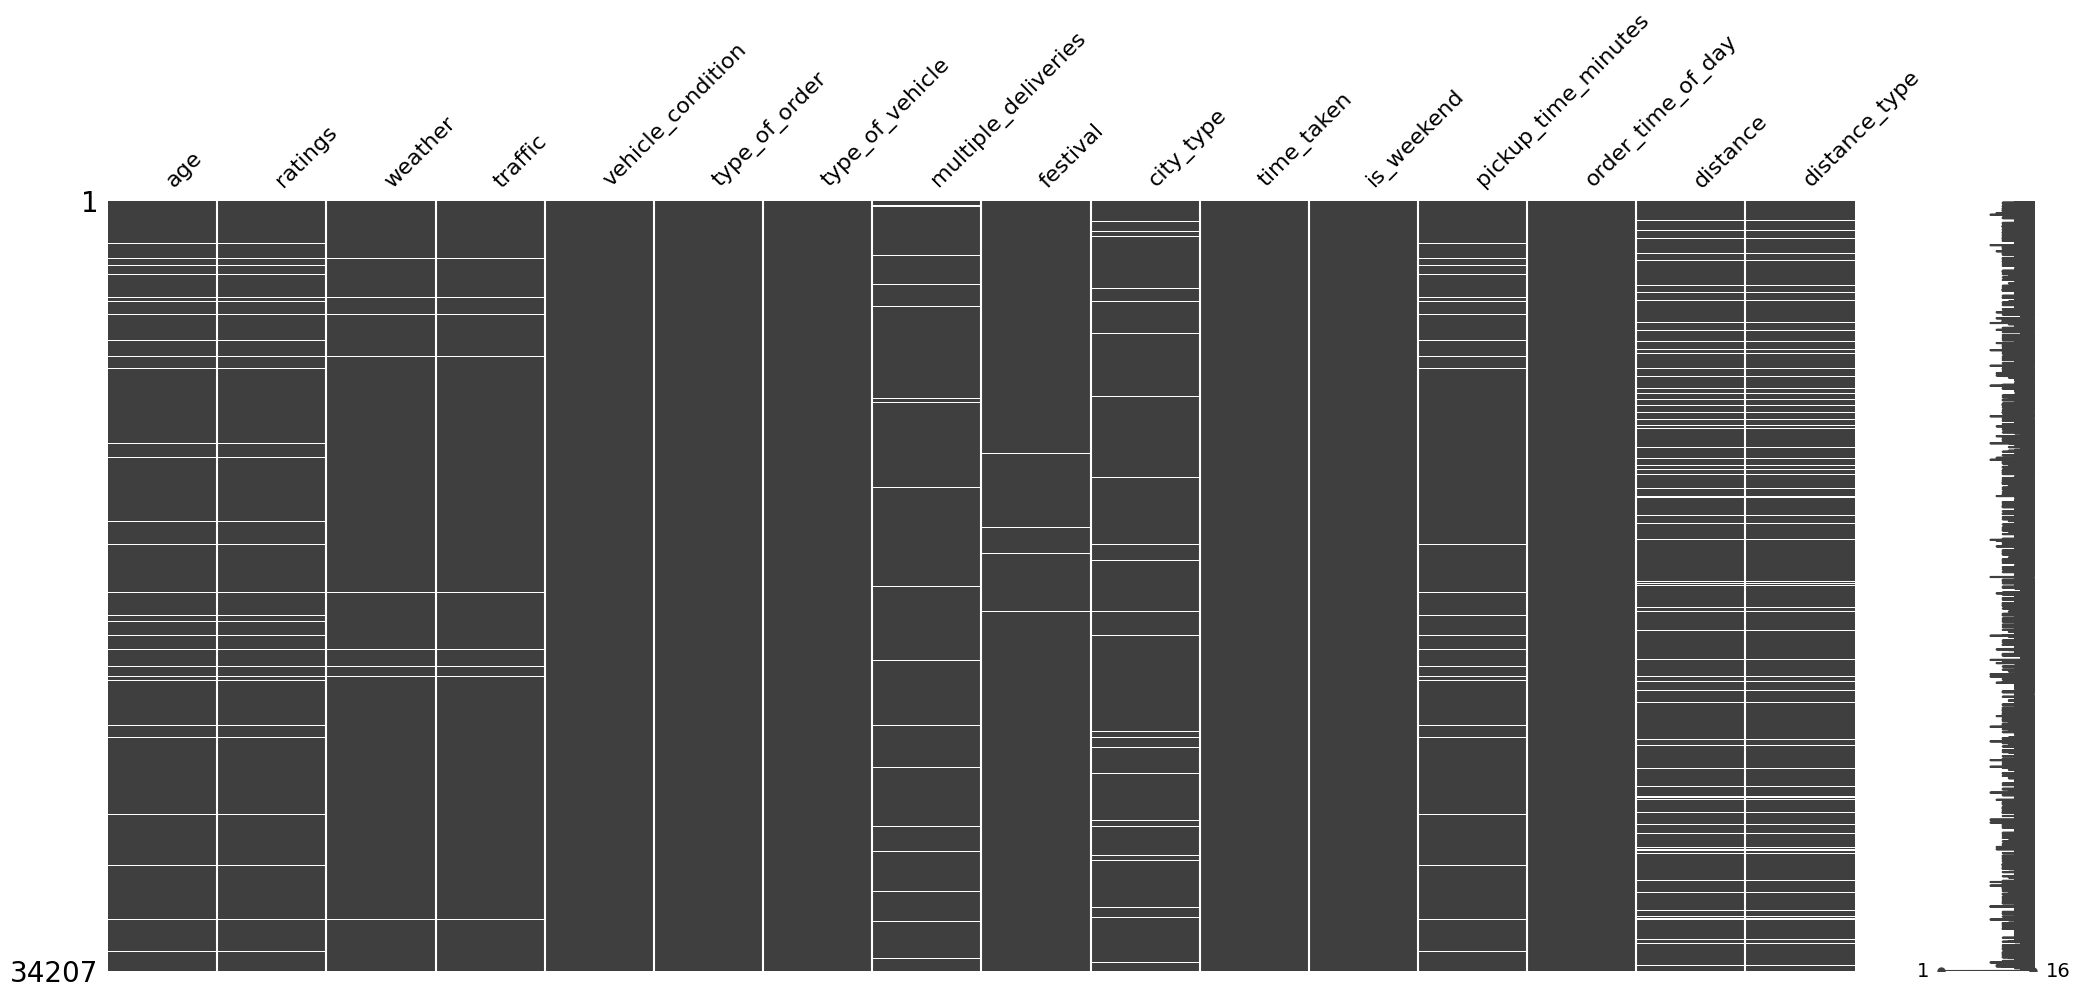

In [ ]:
import missingno as msno

msno.matrix(df)

In [ ]:
missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'is_weekend', 'pickup_time_minutes',
       'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [ ]:
temp_df = df.copy().dropna()

In [ ]:
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2.0,snack,motorcycle,0.0,no,urban,1.0,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2.0,snack,scooter,1.0,no,metropolitian,0.0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0.0,drinks,motorcycle,1.0,no,urban,1.0,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0.0,buffet,motorcycle,1.0,no,metropolitian,0.0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1.0,snack,scooter,1.0,no,metropolitian,1.0,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34200,30.0,4.6,stormy,medium,0.0,snack,motorcycle,1.0,no,metropolitian,0.0,15.0,evening,11.937162,long
34201,30.0,4.9,cloudy,low,2.0,drinks,motorcycle,1.0,no,metropolitian,1.0,5.0,night,10.906325,long
34202,35.0,4.4,windy,low,0.0,meal,motorcycle,1.0,no,metropolitian,0.0,5.0,morning,3.052738,short
34203,39.0,4.7,sandstorms,medium,1.0,snack,scooter,0.0,no,urban,0.0,10.0,evening,4.674144,short


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (22912, 15)
The shape of test data is (5728, 15)


In [ ]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [ ]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [ ]:

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)

np.float64(0.0)

In [ ]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [ ]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [ ]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [ ]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [ ]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [ ]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['low' 'medium' 'jam' 'high']
distance_type ['long' 'very_long' 'short' 'medium']


In [ ]:

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [ ]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                # ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor)
                                # ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [ ]:
X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [ ]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 15.2 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import optuna
from sklearn.metrics import mean_absolute_error

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import StackingRegressor

In [ ]:

best_rf_params = {'n_estimators': 479,
 'criterion': 'squared_error',
 'max_depth': 17,
 'max_features': None,
 'min_samples_split': 9,
 'min_samples_leaf': 2,
 'max_samples': 0.6603673526197067}

best_lgbm_params = {'n_estimators': 154,
 'max_depth': 27,
 'learning_rate': 0.22234435854395157,
 'subsample': 0.7592213724048168,
 'min_child_weight': 20,
 'min_split_gain': 0.004604680609280751,
 'reg_lambda': 97.81002379097947}

best_rf = RandomForestRegressor(**best_rf_params)
best_lgbm = LGBMRegressor(**best_lgbm_params)

In [ ]:
def objective(trial):
    meta_model_name = trial.suggest_categorical("model", ["LR", "KNN", "DT"])

    if meta_model_name == "LR":
        meta = LinearRegression()

    elif meta_model_name == "KNN":
        n_neighbors_knn = trial.suggest_int("n_neighbors_knn", 1, 15)
        weights_knn = trial.suggest_categorical("weights_knn", ["uniform", "distance"])
        meta = KNeighborsRegressor(n_neighbors=n_neighbors_knn,
                                    weights=weights_knn, n_jobs=-1)

    elif meta_model_name == "DT":
        max_depth_dt = trial.suggest_int("max_depth_dt", 1, 10)
        min_samples_split_dt = trial.suggest_int("min_samples_split_dt", 2, 10)
        min_samples_leaf_dt = trial.suggest_int("min_samples_leaf_dt", 1, 10)
        meta = DecisionTreeRegressor(max_depth=max_depth_dt,
                                      min_samples_split=min_samples_split_dt,
                                      min_samples_leaf=min_samples_leaf_dt,
                                      random_state=42)

    # stacking regressor
    stacking_reg = StackingRegressor(estimators=[("rf", best_rf),
                                                  ("lgbm", best_lgbm)],
                                      final_estimator=meta,
                                      cv=5, n_jobs=-1)

    # build transformed regressor
    model = TransformedTargetRegressor(regressor=stacking_reg,
                                        transformer=pt)

    # train the model
    model.fit(X_train_trans, y_train)

    # get the predictions
    y_pred_test = model.predict(X_test_trans)

    # mean absolute error
    error = mean_absolute_error(y_test, y_pred_test)

    return error


# optimize the objective function
study.optimize(objective, n_trials=20, n_jobs=-1, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

NameError: name 'study' is not defined

In [ ]:
best_params = study.best_params

best_params

In [ ]:
study.trials_dataframe()["params_model"].value_counts()

In [ ]:
study.trials_dataframe().groupby(by="params_model")['value'].mean().sort_values()

In [ ]:

study.best_value

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_parallel_coordinate(study,params=["model"])